## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [11]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.cm as cm
from scipy.stats import weibull_min
from windrose import WindroseAxes

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [3]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Từ các yếu tố sau: 

| Biến                       | Đo cái gì                                                        |
| -------------------------- | ---------------------------------------------------------------- |
| `u_component_of_wind_10m`  | Gió hướng đông - tây ở mốc 10m, dương = thổi về hướng đông, m/s  |
| `v_component_of_wind_10m`  | Gió hướng bắc - nam ở mốc 10m, dương = thổi về hướng bắc, m/s    |
| `u_component_of_wind_100m` | Gió hướng đông - tây ở mốc 100m, dương = thổi về hướng đông, m/s |
| `v_component_of_wind_100m` | Gió hướng bắc - nam ở mốc 100m, dương = thổi về hướng bắc, m/s   |

Xử lý dữ liệu và nhóm lại các biến theo các danh mục khác nhau. Trong số này:
- ws10, ws100: Tốc độ gió tại độ cao 10m và 100m (m/s)
- wd10, wd100: Hướng gió tại độ cao 10m và 100m (° / độ)
- alpha: Gió đứt - sự thay đổi đột ngột về tốc độ hoặc hướng gió
- wpd10, wpd100: Mật độ công suất gió tại độ cao 10m và 100m (W/m²)

Ngoài ra như thường lệ là các chỉ số theo tháng, chỉ số trung bình từng tháng và chỉ số dị thường của gió.

In [4]:
def circular_mean_daily(u, v):
    u_mean = u.resample(time="1D").mean()
    v_mean = v.resample(time="1D").mean()
    return (270 - np.degrees(np.arctan2(v_mean, u_mean))) % 360

In [5]:
def get_wind_data_optimized(folder_path, wind_paths):
    # Open each file separately
    datasets = [preprocess(xr.open_dataset(os.path.join(folder_path, p))) for p in wind_paths]
    
    # One lazy array per file
    lazy = [ds[list(ds.data_vars)[0]].mean(dim=["latitude", "longitude"]).resample(time="1D").mean() for ds in datasets]

    # Compute all files in parallel in one shot
    computed = dask.compute(*lazy)  

    for ds in datasets:
        ds.close()

    # Merge into one Dataset
    wind_vars = [list(ds.data_vars)[0] for ds in datasets]
    daily_wind = xr.Dataset({v: arr for v, arr in zip(wind_vars, computed)})

    u10  = daily_wind["u10"]
    v10  = daily_wind["v10"]
    u100 = daily_wind["u100"]
    v100 = daily_wind["v100"]

    # Wind speed
    ws10  = np.sqrt(u10**2  + v10**2)    # m/s at 10m
    ws100 = np.sqrt(u100**2 + v100**2)   # m/s at 100m

    # Wind direction — meteorological convention:
    # 0° = wind FROM north, 90° = wind FROM east, 180° = FROM south, 270° = FROM west
    # atan2 returns mathematical angle; convert to met convention:
    wd10  = (270 - np.degrees(np.arctan2(v10,  u10)))  % 360
    wd100 = (270 - np.degrees(np.arctan2(v100, u100))) % 360

    # Vertical wind shear — power law exponent α
    # ws100 / ws10 = (100/10)^α  →  α = log(ws100/ws10) / log(10)
    alpha = np.log((ws100 + 1e-6) / (ws10 + 1e-6)) / np.log(10.0)
    alpha = alpha.clip(-1, 2)    # clip physically unrealistic values

    # Wind power density — proportional to cube of wind speed
    # WPD = 0.5 × ρ × v³, use standard air density ρ = 1.225 kg/m³
    wpd10  = 0.5 * 1.225 * ws10**3    # W/m²
    wpd100 = 0.5 * 1.225 * ws100**3   # W/m²

    # Daily aggregates
    daily_ws10 = ws10.resample(time="1D").mean()
    daily_ws100 = ws100.resample(time="1D").mean()
    daily_wd10 = wd10.resample(time="1D").mean()   # use with caution — circular mean below
    daily_wd100 = wd100.resample(time="1D").mean()
    daily_alpha = alpha.resample(time="1D").mean()
    daily_wpd10 = wpd10.resample(time="1D").mean()
    daily_wpd100 = wpd100.resample(time="1D").mean()

    daily_wd10_circ = circular_mean_daily(u10, v10)
    daily_wd100_circ = circular_mean_daily(u100, v100)

    monthly_ws10 = daily_ws10.resample(time="1ME").mean()
    monthly_ws100 = daily_ws100.resample(time="1ME").mean()
    monthly_wpd100 = daily_wpd100.resample(time="1ME").mean()

    clim_ws10 = daily_ws10.groupby("time.month").mean("time")
    clim_ws100 = daily_ws100.groupby("time.month").mean("time")
    clim_alpha = daily_alpha.groupby("time.month").mean("time")
    clim_wpd100 = daily_wpd100.groupby("time.month").mean("time")

    anom_ws10 = daily_ws10.groupby("time.month")  - clim_ws10
    anom_ws100 = daily_ws100.groupby("time.month") - clim_ws100

    df_daily = xr.Dataset({
        "ws10": daily_ws10,
        "ws100": daily_ws100,
        "wd10": daily_wd10,
        "wd100": daily_wd100,
        "wpd10": daily_wpd10,
        "wpd100": daily_wpd100,
        "wd10_circ": daily_wd10_circ,
        "wd100_circ": daily_wd100_circ,
        "alpha": daily_alpha,
        "anom_ws10": anom_ws10,
        "anom_ws100": anom_ws100
    }).to_dataframe()

    df_monthly = xr.Dataset({
        "ws10": monthly_ws10,
        "ws100": monthly_ws100,
        "wpd100": monthly_wpd100
    }).to_dataframe()

    df_clim = xr.Dataset({
        "ws10": clim_ws10,
        "ws100": clim_ws100,
        "alpha": clim_alpha,
        "wpd100": clim_wpd100
    }).to_dataframe()

    return df_daily, df_monthly, df_clim

In [6]:
wind_paths = ['10m_u_component_of_wind_merged.nc', '10m_v_component_of_wind_merged.nc', '100m_u_component_of_wind_merged.nc', '100m_v_component_of_wind_merged.nc']
df_daily, df_monthly, df_clim = get_wind_data_optimized(FOLDER_PATH, wind_paths)

In [7]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,ws10,ws100,wd10,wd100,wpd10,wpd100,wd10_circ,wd100_circ,alpha,month,anom_ws10,anom_ws100
0,1980-01-01,1.876731,2.579703,111.502182,114.240952,4.048671,10.515140,111.502182,114.240952,0.138167,1,-1.108523,-1.474002
1,1980-01-02,1.701384,2.284943,101.685928,104.034729,3.016566,7.306887,101.685928,104.034729,0.128073,1,-1.283871,-1.768761
2,1980-01-03,1.899899,2.607155,87.521729,90.584106,4.200471,10.854425,87.521729,90.584106,0.137436,1,-1.085355,-1.446549
3,1980-01-04,3.979387,5.428730,52.602997,54.775208,38.597088,97.994331,52.602997,54.775208,0.134882,1,0.994132,1.375026
4,1980-01-05,4.152929,5.635003,52.913940,54.409943,43.870197,109.594452,52.913940,54.409943,0.132540,1,1.167674,1.581298


In [8]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,ws10,ws100,wpd100
0,1980-01-31,2.789698,3.791312,44.406696
1,1980-02-29,2.964972,4.031493,51.873886
2,1980-03-31,2.384432,3.443707,31.231346
3,1980-04-30,2.330621,3.336436,28.273878
4,1980-05-31,1.754771,2.520073,16.045679


In [9]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,ws10,ws100,alpha,wpd100
0,1,2.985255,4.053705,0.132302,60.326176
1,2,2.546766,3.492791,0.138206,40.070026
2,3,2.269193,3.198918,0.150918,28.729458
3,4,2.058029,2.928483,0.152823,21.034016
4,5,1.892670,2.708138,0.153530,18.926193


## 1. Biểu đồ hướng gió và tốc độ gió theo mùa

Biểu đồ này cho ta thấy hướng gió và tốc độ gió theo mùa. Độ dài của cột cho ta thấy tần suất gió thổi theo hướng đó cùng với đó là tốc độ gió thổi. Vào các giai đoạn mùa khác nhau trong năm thì phân bố gió cũng khác nhau:
- Mùa xuân: Gió thổi phân tán từ nhiều hướng, do vừa qua thời khắc chuyển mùa và hoàn lưu chưa ổn định. Tốc độ gió thấp nhất trong năm cùng với tần suất cũng thấp.
- Mùa hạ: Gió thổi tập trung từ hướng Tây Nam, với tốc độ cao hơn rõ rệt, cùng với tần suất gió cao nhất trong năm.
- Mùa thu: Gió thổi dần theo hướng Đông Bắc, tốc độ trung bình và tần suất cũng ít hơn mùa hạ.
- Mùa đông: Gió thổi tập trung rõ rệt về hướng Bắc và Đông Bắc, tốc độ cao, cùng với tần suất nhiều hơn hẳn so với mùa thu.

Từ đó ta thấy, khu vực này chịu tác động rõ rệt từ gió mùa Đông Bắc và gió mùa Tây Nam.

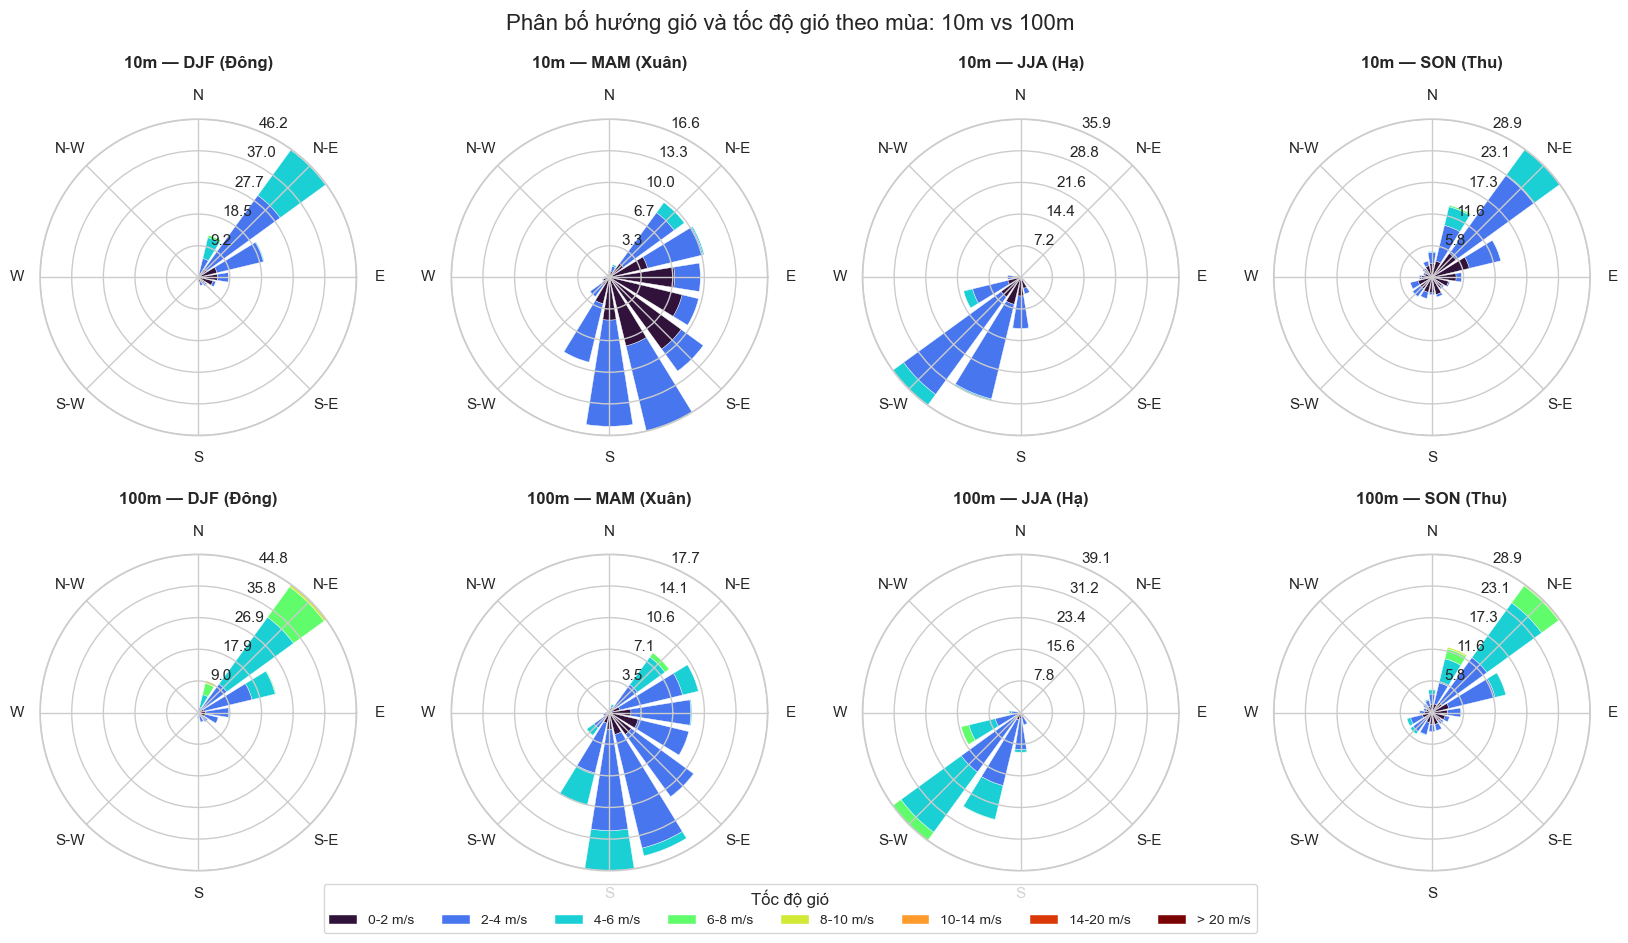

In [12]:
season_months = {
    "DJF (Đông)": [12, 1, 2],
    "MAM (Xuân)": [3, 4, 5],
    "JJA (Hạ)": [6, 7, 8],
    "SON (Thu)": [9, 10, 11]
}

# Define Speed Bins and Heights
speed_bins = [0, 2, 4, 6, 8, 10, 14, 20]
heights = [
    {"label": "10m", "ws": "ws10", "wd": "wd10_circ"},
    {"label": "100m", "ws": "ws100", "wd": "wd100_circ"}
]

# 3. Create the Plot
fig = plt.figure(figsize=(20, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Counter for subplot indexing
plot_index = 1

for h_idx, h in enumerate(heights):
    for s_name, s_months in season_months.items():
        # Filter data for the specific season
        sub_df = df_daily[df_daily['month'].isin(s_months)]
        
        # Add subplot with windrose projection
        ax = fig.add_subplot(2, 4, plot_index, projection="windrose")
        
        # Plot the bars
        ax.bar(sub_df[h['wd']], sub_df[h['ws']], 
               bins=speed_bins, 
               normed=True,     
               opening=0.8,          
               edgecolor="white", 
               linewidth=0.3,
               cmap=cm.turbo)      
        
        # Formatting
        ax.set_title(f"{h['label']} — {s_name}", fontsize=12, fontweight='bold', pad=15)
        plot_index += 1

legend_labels = [f"{speed_bins[i]}-{speed_bins[i+1]} m/s" for i in range(len(speed_bins)-1)]
legend_labels.append(f"> {speed_bins[-1]} m/s")

fig.legend(
    labels=legend_labels,
    loc="lower center",
    ncol=len(speed_bins),
    title="Tốc độ gió",
    fontsize=10,
    bbox_to_anchor=(0.5, 0.05)
)

plt.suptitle("Phân bố hướng gió và tốc độ gió theo mùa: 10m vs 100m", fontsize=16, y=0.98)
plt.show()

## 2. Chỉ số khí hậu về tốc độ gió qua các tháng

Biểu đồ thể hiện tốc độ gió ở độ cao 10m và 100m theo tháng, cùng với khung 1STD để cho thấy sự khác biệt ở 2 mốc độ cao khác nhau. Tỉ lệ ws100 / ws10 là mức độ tăng tốc gió - đo xem ở mốc 100m thì sẽ nhanh hơn mốc 10m là bao nhiêu.

Từ biểu đồ, ta thấy rõ được 2 đỉnh gió với tốc độ cao nhất là vào tháng 12 và tháng 6, đúng cấu trúc của chế độ gió mùa. Về mức độ tăng tốc gió, ta thấy mức này mạnh nhất vào mùa hè. Mức tăng này tăng dần thể hiện rằng bầu khí quyển đang dần trở nên ổn định hơn.

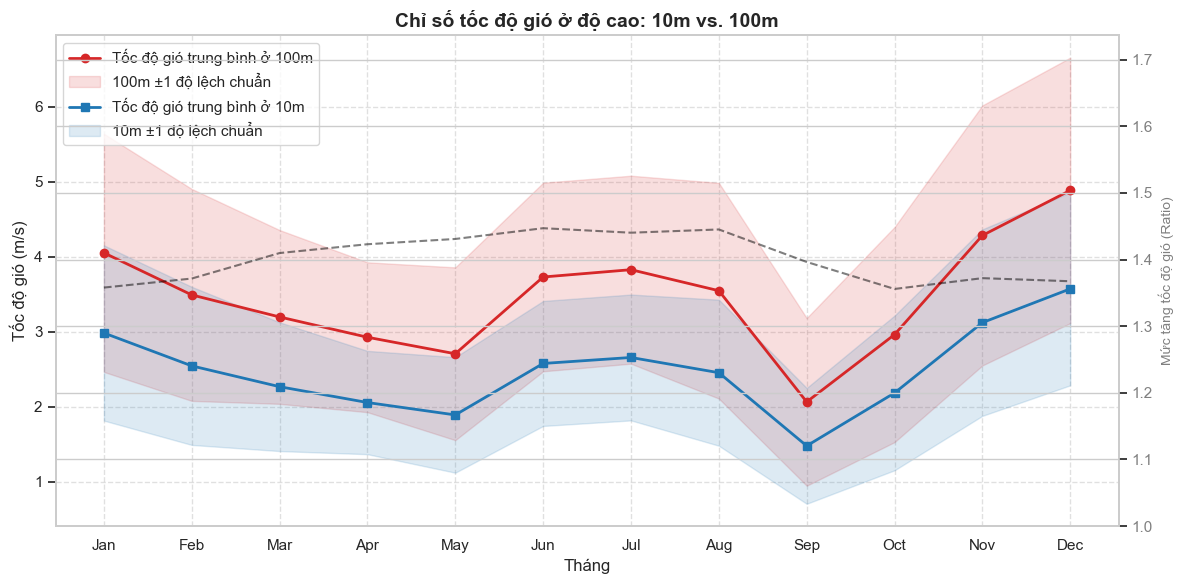

In [13]:
clim_stats = df_daily.groupby('month').agg({
    'ws10': ['mean', 'std'],
    'ws100': ['mean', 'std']
}).reset_index()

# Flatten the multi-index columns for easier plotting
clim_stats.columns = ['month', 'ws10_mean', 'ws10_std', 'ws100_mean', 'ws100_std']

# Calculate the speed-up factor (ratio) for the explanation
clim_stats['ratio'] = clim_stats['ws100_mean'] / clim_stats['ws10_mean']

fig, ax1 = plt.subplots(figsize=(12, 6))

months = clim_stats['month']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot WS100 (100m)
ax1.plot(months, clim_stats['ws100_mean'], color='tab:red', marker='o', linewidth=2, label='Tốc độ gió trung bình ở 100m')
ax1.fill_between(months, 
                 clim_stats['ws100_mean'] - clim_stats['ws100_std'], 
                 clim_stats['ws100_mean'] + clim_stats['ws100_std'], 
                 color='tab:red', alpha=0.15, label='100m ±1 độ lệch chuẩn')

# Plot WS10 (10m)
ax1.plot(months, clim_stats['ws10_mean'], color='tab:blue', marker='s', linewidth=2, label='Tốc độ gió trung bình ở 10m')
ax1.fill_between(months, 
                 clim_stats['ws10_mean'] - clim_stats['ws10_std'], 
                 clim_stats['ws10_mean'] + clim_stats['ws10_std'], 
                 color='tab:blue', alpha=0.15, label='10m ±1 độ lệch chuẩn')

# Formatting Main Axis
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Tốc độ gió (m/s)', fontsize=12)
ax1.set_xticks(months)
ax1.set_xticklabels(month_names)
ax1.set_title('Chỉ số tốc độ gió ở độ cao: 10m vs. 100m', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# 4. Optional: Add a second axis to show the speed-up ratio
ax2 = ax1.twinx()
ax2.plot(months, clim_stats['ratio'], color='black', linestyle='--', alpha=0.5, label='Speed-up Ratio (WS100/WS10)')
ax2.set_ylabel('Mức tăng tốc độ gió (Ratio)', fontsize=10, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(1, clim_stats['ratio'].max() * 1.2) # Adjust to show the gap

plt.tight_layout()
plt.show()

## 3. Xu hướng dài hạn của tốc độ gió và chỉ số Alpha

Biểu đồ đo xu hướng dài hạn của tốc độ gió ở độ cao 10m, 100m cũng như chỉ số Alpha. Từ biểu đồ này, ta có thể thấy được rằng tốc độ gió được duy trì ở mốc khá ổn định trong suốt 45 năm, không thật sự có quá nhiều biến động mạnh ở độ cao 10m và 100m. Biến động chủ yếu là giữa các năm với nhau.

Xét về chỉ số Alpha, cũng không có sự biến động quá mạnh mẽ, chỉ số đủ nhỏ, đặc trưng cho địa hình ven biển với ít ma sát bề mặt. Điều này giúp ta khẳng định gió ở đây bền vững, ổn định

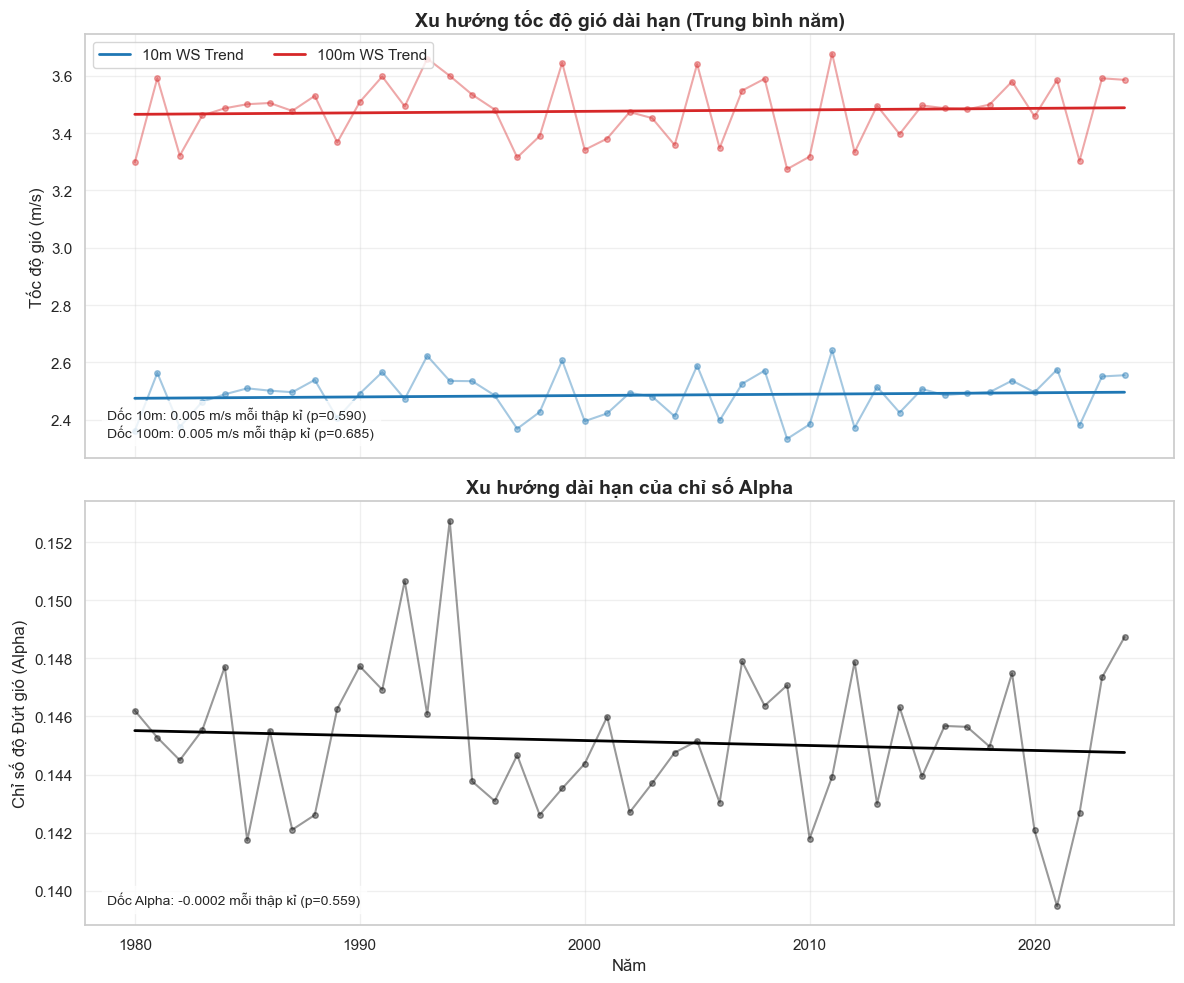

In [14]:
df_daily['time'] = pd.to_datetime(df_daily['time'])
df_daily['year'] = df_daily['time'].dt.year

annual_df = df_daily.groupby('year').agg({
    'ws10': 'mean',
    'ws100': 'mean',
    'alpha': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Function to calculate and plot trend
def plot_trend(ax, x, y, color, label, unit):
    # Linear Regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    trend_line = intercept + slope * x
    
    # Plot raw annual means
    ax.plot(x, y, 'o-', color=color, alpha=0.4, markersize=4)
    # Plot trend line
    ax.plot(x, trend_line, color=color, linewidth=2, label=f"{label} Trend")
    
    # Calculate slope per decade
    slope_decade = slope * 10
    return slope_decade, p_value

# Top Panel: Wind Speeds
s10, p10 = plot_trend(ax1, annual_df['year'], annual_df['ws10'], 'tab:blue', '10m WS', 'm/s')
s100, p100 = plot_trend(ax1, annual_df['year'], annual_df['ws100'], 'tab:red', '100m WS', 'm/s')

ax1.set_ylabel('Tốc độ gió (m/s)', fontsize=12)
ax1.set_title('Xu hướng tốc độ gió dài hạn (Trung bình năm)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', ncol=2)
ax1.grid(True, alpha=0.3)

# Annotate Slopes
text_ws = (f"Dốc 10m: {s10:.3f} m/s mỗi thập kỉ (p={p10:.3f})\n"
           f"Dốc 100m: {s100:.3f} m/s mỗi thập kỉ (p={p100:.3f})")
ax1.text(0.02, 0.05, text_ws, transform=ax1.transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

# Bottom Panel: Alpha (Wind Shear Exponent)
sa, pa = plot_trend(ax2, annual_df['year'], annual_df['alpha'], 'black', 'Shear Alpha', '')

ax2.set_ylabel('Chỉ số độ Đứt gió (Alpha)', fontsize=12)
ax2.set_xlabel('Năm', fontsize=12)
ax2.set_title('Xu hướng dài hạn của chỉ số Alpha', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Annotate Slope for Alpha
text_alpha = f"Dốc Alpha: {sa:.4f} mỗi thập kỉ (p={pa:.3f})"
ax2.text(0.02, 0.05, text_alpha, transform=ax2.transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 4. Xu hướng mật độ công suất gió tại 100m và tần suất gió vượt ngưỡng vận hành

Từ biểu đồ, khi đánh giá mật độ công suất gió, ta thấy được rằng qua nhiều năm, chưa có nhiều biến động thật sự về gió, những biến động giữa các năm gần nhau thì lại rất lớn. Chỉ có xu hướng đáng chú ý duy nhất là xu hướng tăng nhẹ qua mỗi thập kỉ.

Tương tự là số ngày gió vượt ngưỡng 3m/s. Số lượng ngày này phân bố không đều qua các năm, biến động lớn nên cần tính toán cẩn thận nếu muốn làm gì đó liên quan đến gió.

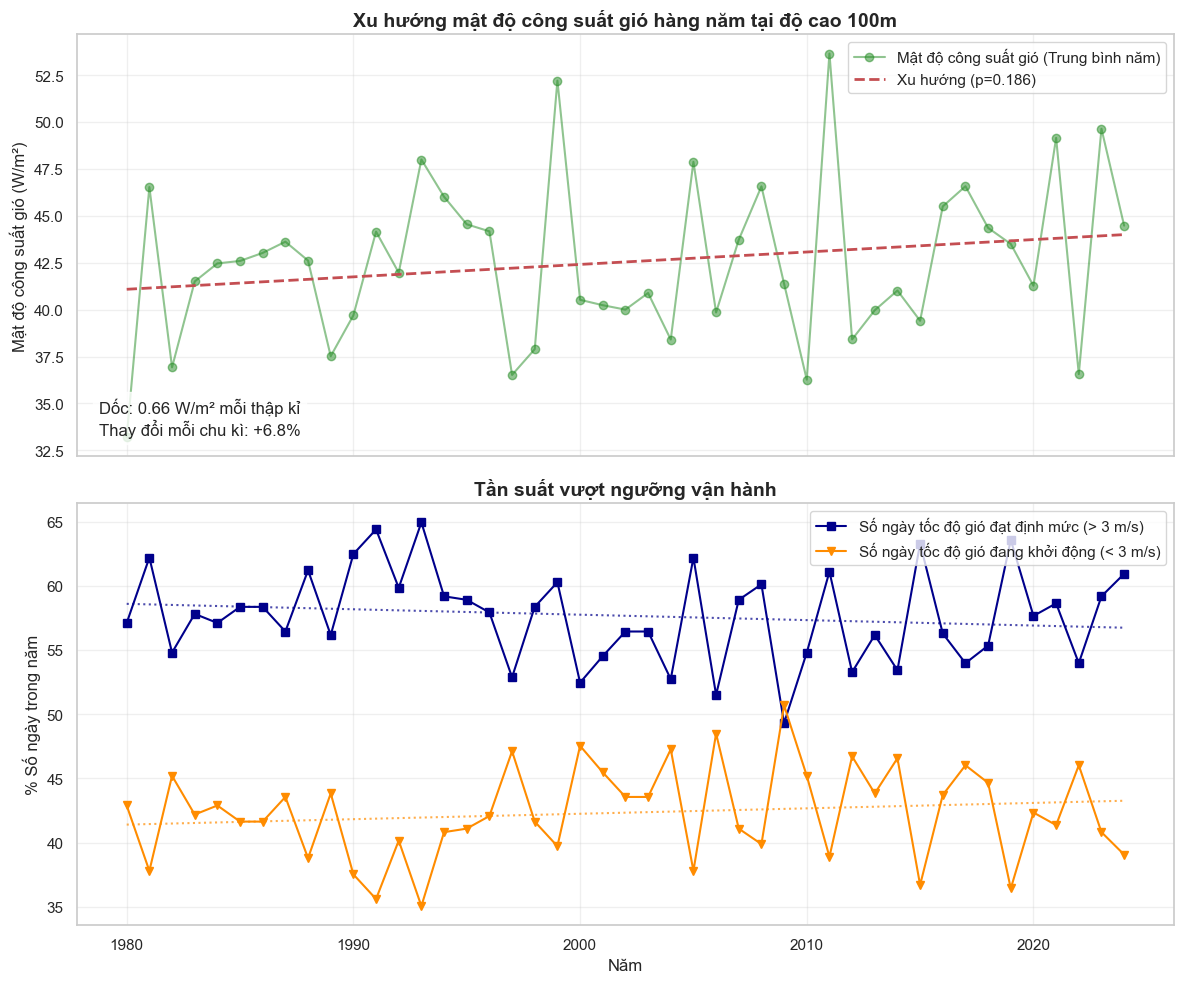

In [15]:
df_daily['year'] = df_daily['time'].dt.year

# Create flags for thresholds (1 if True, 0 if False)
df_daily['is_high'] = (df_daily['ws100'] >= 3).astype(int)
df_daily['is_low'] = (df_daily['ws100'] < 3).astype(int)

# Group by year
annual_wpd = df_daily.groupby('year').agg({
    'wpd100': 'mean',
    'is_high': 'mean',  # This becomes the fraction of days/year
    'is_low': 'mean'    # This becomes the fraction of days/year
}).reset_index()

# Convert fractions to percentages for easier reading
annual_wpd['high_pct'] = annual_wpd['is_high'] * 100
annual_wpd['low_pct'] = annual_wpd['is_low'] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Wind Power Density (100m)
x = annual_wpd['year']
y_wpd = annual_wpd['wpd100']

slope, intercept, r_val, p_val, std_err = linregress(x, y_wpd)
ax1.plot(x, y_wpd, 'o-', color='forestgreen', alpha=0.5, label='Mật độ công suất gió (Trung bình năm)')
ax1.plot(x, intercept + slope*x, 'r--', linewidth=2, label=f'Xu hướng (p={p_val:.3f})')

# Calculate total % change over the period
total_change_pct = ((slope * (x.max() - x.min())) / y_wpd.mean()) * 100

ax1.set_ylabel('Mật độ công suất gió (W/m²)', fontsize=12)
ax1.set_title('Xu hướng mật độ công suất gió hàng năm tại độ cao 100m', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Annotation for WPD
ax1.text(0.02, 0.05, f"Dốc: {slope*10:.2f} W/m² mỗi thập kỉ\nThay đổi mỗi chu kì: {total_change_pct:+.1f}%", 
         transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Capacity Factor Proxies (Thresholds)
ax2.plot(x, annual_wpd['high_pct'], 's-', color='darkblue', label='Số ngày tốc độ gió đạt định mức (> 3 m/s)')
ax2.plot(x, annual_wpd['low_pct'], 'v-', color='darkorange', label='Số ngày tốc độ gió đang khởi động (< 3 m/s)')

# Add trend lines for thresholds
for col, color in [('high_pct', 'darkblue'), ('low_pct', 'darkorange')]:
    s, i, _, p, _ = linregress(x, annual_wpd[col])
    ax2.plot(x, i + s*x, color=color, linestyle=':', alpha=0.7)

ax2.set_ylabel('% Số ngày trong năm', fontsize=12)
ax2.set_xlabel('Năm', fontsize=12)
ax2.set_title('Tần suất vượt ngưỡng vận hành', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Heatmap dị thường tốc độ gió trong các năm tại độ cao 10m

Từ heatmap này, ta có thể thấy được rằng không có hệ thống phân bố gió rõ ràng theo năm, không thấy sự liên tục giữa các màu sắc. Các tháng trong mùa hạ dường như ổn định hơn các tháng trong mùa đông. Phần lớn những dị thường nằm trong khoảng 0.5m/s, có rất hiếm các dị thường trong khoảng cực đoan.

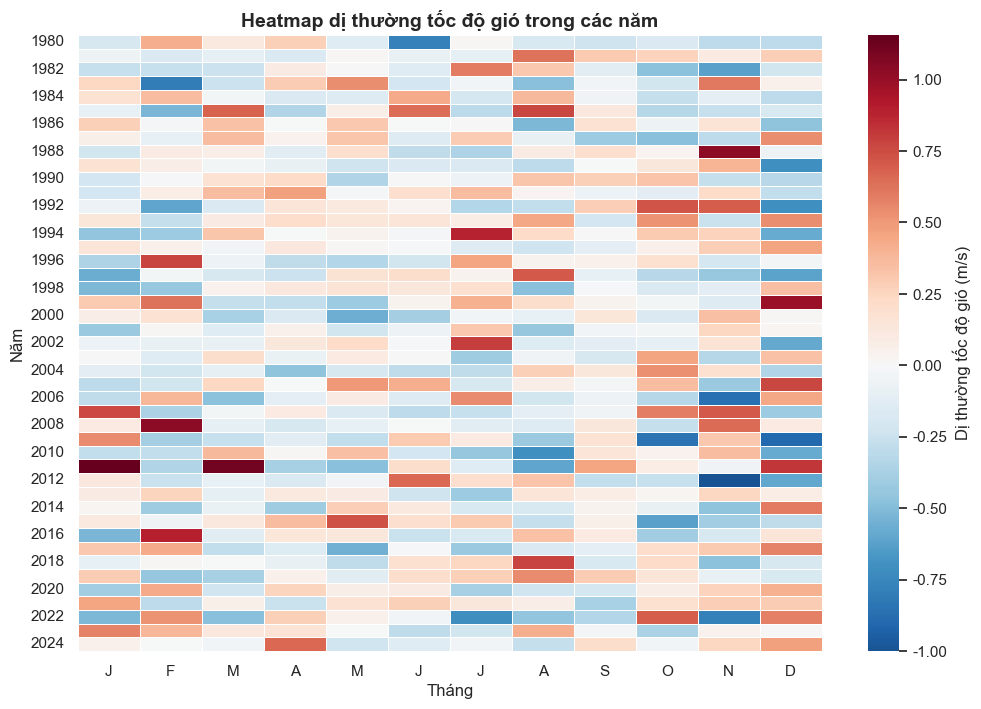

In [16]:
heatmap_data = df_daily.pivot_table(index='year', columns='month', values='anom_ws10', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Dị thường tốc độ gió (m/s)'},
            linewidths=.5)
plt.title('Heatmap dị thường tốc độ gió trong các năm', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Năm')
plt.xticks(ticks=np.arange(12)+0.5, labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.show()

## 6. Độ nhất quán của hướng gió mùa Tây Nam trong mùa hạ

Đây là biểu đồ về độ nhất quán của gió góc Nam - Tây Nam, phần lớn ngày trong mùa hạ thường thổi gió mùa Tây Nam ở khu vực này là hợp lý.

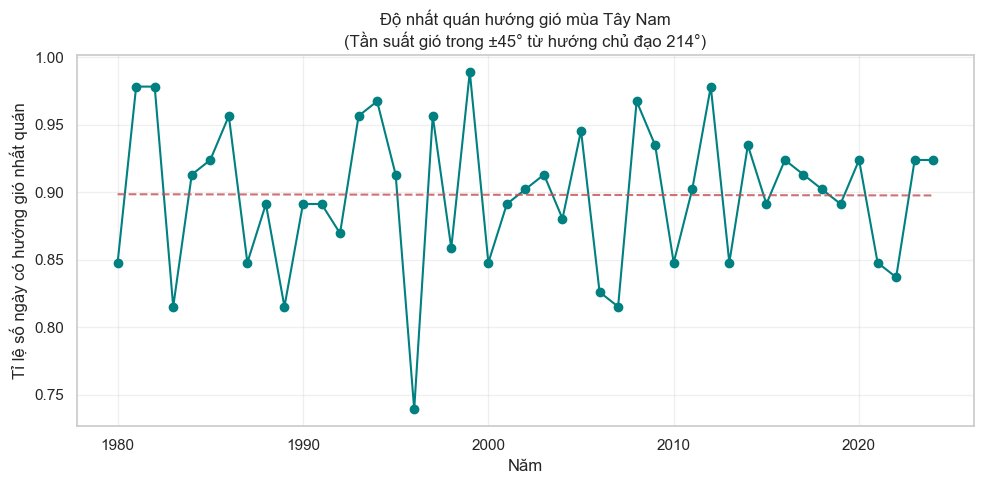

In [26]:
import scipy.stats as stats

monsoon_data = df_daily[df_daily['month'].isin([6, 7, 8])].copy()

angles_rad = np.deg2rad(monsoon_data['wd10_circ'])
dom_dir = np.rad2deg(stats.circmean(angles_rad))  # ~212-214°

# Define "Within 45 degrees" logic (handling 360/0 wrap-around)
def is_in_monsoon_stream(wd, target):
    diff = np.abs(wd - target)
    return (diff <= 45) | (diff >= 315)

monsoon_data['consistent'] = is_in_monsoon_stream(monsoon_data['wd10_circ'], dom_dir)
monsoon_consistency = monsoon_data.groupby('year')['consistent'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monsoon_consistency.index, monsoon_consistency.values, 'o-', color='teal')

z = np.polyfit(monsoon_consistency.index, monsoon_consistency.values, 1)
p = np.poly1d(z)
plt.plot(monsoon_consistency.index, p(monsoon_consistency.index), "r--", alpha=0.8)

plt.title(
    f'Độ nhất quán hướng gió mùa Tây Nam\n'
    f'(Tần suất gió trong ±45° từ hướng chủ đạo {dom_dir:.0f}°)',
    fontsize=12
)
plt.ylabel('Tỉ lệ số ngày có hướng gió nhất quán')
plt.xlabel('Năm')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Biểu đồ chu kì và tần suất của chỉ số Alpha

Về mặt chu kì của chỉ số Alpha, thì chu kì qua các năm chỉ ra rằng chỉ số thường cao nhất vào khoảng tháng 6 đến tháng 8, thấp đi đột ngột vào tháng 9, tháng 10 và phục hồi dần vào các tháng mùa đông sau đó.

Về tần suất, số ngày gió bị đứt gãy mạnh rất ít, một số năm còn không có, chủ yếu là gió đồng đều theo độ cao và không bị đứt gãy. Vậy nên có thể kết luận gió ở khu vực này ổn định, an toàn

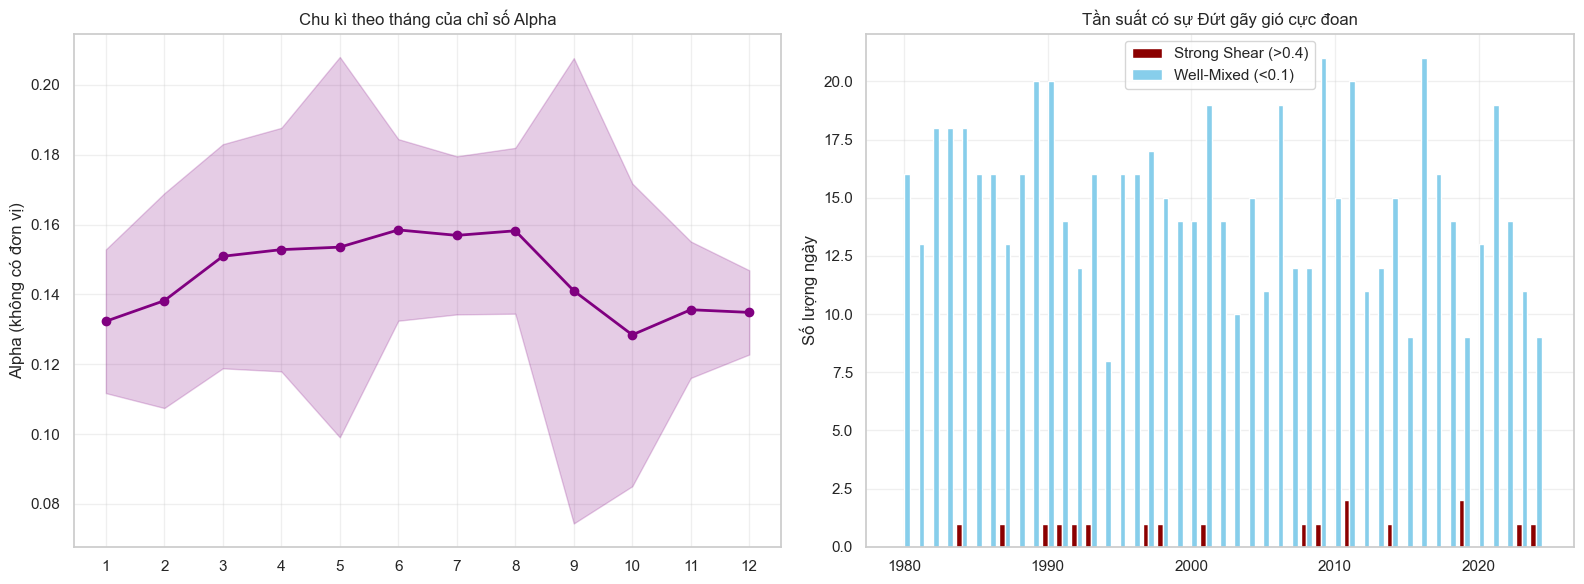

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Monthly Climatology of Alpha
alpha_clim = df_daily.groupby('month')['alpha'].agg(['mean', 'std'])
ax1.plot(alpha_clim.index, alpha_clim['mean'], color='purple', linewidth=2, marker='o')
ax1.fill_between(alpha_clim.index, alpha_clim['mean']-alpha_clim['std'], 
                 alpha_clim['mean']+alpha_clim['std'], color='purple', alpha=0.2)
ax1.set_title('Chu kì theo tháng của chỉ số Alpha', fontsize=12)
ax1.set_ylabel('Alpha (không có đơn vị)')
ax1.set_xticks(range(1, 13))
ax1.grid(True, alpha=0.3)

# Extreme Shear Event Counts
high_shear = df_daily[df_daily['alpha'] > 0.4].groupby('year').size()
low_shear = df_daily[df_daily['alpha'] < 0.1].groupby('year').size()

years = sorted(df_daily['year'].unique())
ax2.bar(np.array(years)-0.2, [high_shear.get(y, 0) for y in years], width=0.4, label='Strong Shear (>0.4)', color='darkred')
ax2.bar(np.array(years)+0.2, [low_shear.get(y, 0) for y in years], width=0.4, label='Well-Mixed (<0.1)', color='skyblue')

ax2.set_title('Tần suất có sự Đứt gãy gió cực đoan', fontsize=12)
ax2.set_ylabel('Số lượng ngày')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Biểu đồ Weibull theo thập kỉ về tốc độ gió ở độ cao 100m

Qua từng thập kỉ, ta thấy được chỉ số k và c ổn định, với k là tham số để định nên hình dạng và c là tỉ lệ với tốc độ gió. Tất cả các đường gần như là trùng nhau, phân bố Weibull cực kì ổn định trong suốt 45 năm. Điều này lại càng khẳng định là gió ở khu vực rất ổn định, không bị nhiều xáo trộn mạnh.

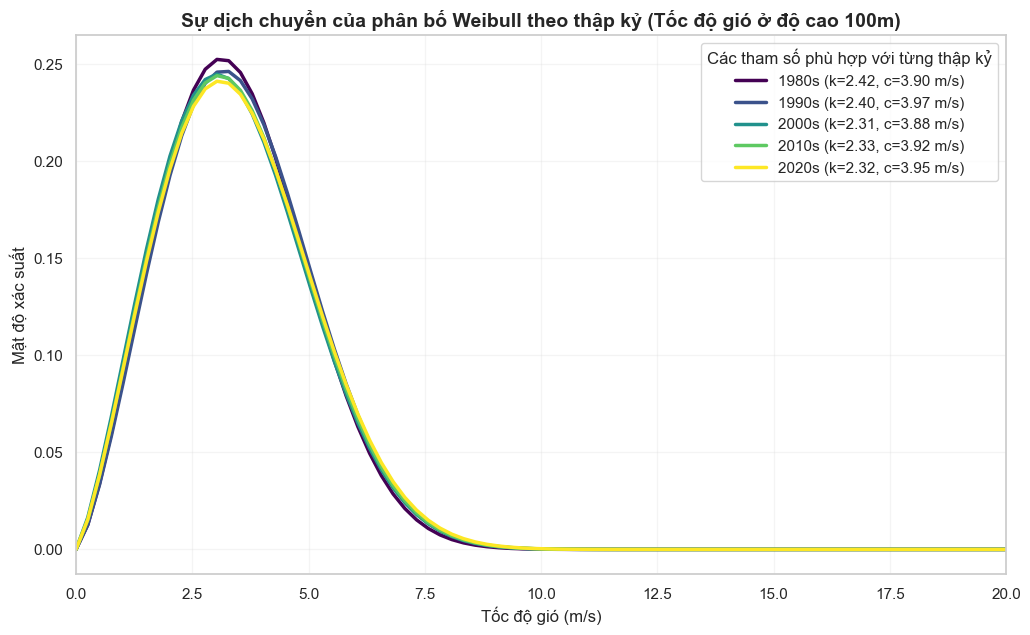

In [19]:
plt.figure(figsize=(12, 7))
x_range = np.linspace(0, 25, 100)
colors = plt.cm.viridis(np.linspace(0, 1, 5))

# Define decades
df_daily['decade'] = (df_daily['year'] // 10) * 10
decades = sorted(df_daily['decade'].unique())

for i, decade in enumerate(decades):
    data = df_daily[df_daily['decade'] == decade]['ws100'].dropna()
    
    # Fit Weibull (loc fixed to 0)
    shape, loc, scale = weibull_min.fit(data, floc=0)
    
    # Generate PDF
    pdf = weibull_min.pdf(x_range, shape, loc, scale)
    
    plt.plot(x_range, pdf, color=colors[i], lw=2.5, 
             label=f"{decade}s (k={shape:.2f}, c={scale:.2f} m/s)")

plt.title('Sự dịch chuyển của phân bố Weibull theo thập kỷ (Tốc độ gió ở độ cao 100m)', fontsize=14, fontweight='bold')
plt.xlabel('Tốc độ gió (m/s)')
plt.ylabel('Mật độ xác suất')
plt.legend(title="Các tham số phù hợp với từng thập kỷ")
plt.grid(True, alpha=0.2)
plt.xlim(0, 20)
plt.show()